# Vehicle Troubleshooting Chatbot - NLP Preprocessing

This notebook handles NLP preprocessing for the vehicle troubleshooting chatbot supporting:
- Main dataset (Vehicle issues for Toyota Aqua, Prius, Corolla, Alto, Vitz)
- Fallback dataset (Diagnostic questions and generic advice)
- Bilingual support (English & Sinhala)

## Table of Contents
1. Data Loading & Exploration
2. Text Preprocessing Functions
3. Dataset Analysis
4. Feature Engineering
5. Vectorization & Embeddings
6. Export Processed Data

## 1. Import Libraries

In [12]:
# Data manipulation
import pandas as pd
import numpy as np
import json
import re
from collections import Counter

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ML & Embeddings
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Google Gemini API (for embeddings)
import google.generativeai as genai

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Download NLTK Data

In [13]:
# Download required NLTK data
import ssl

# Fix SSL certificate issues
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download required NLTK packages (updated for newer NLTK versions)
nltk_packages = [
    'punkt',                    # Original punkt
    'punkt_tab',                # New punkt for NLTK 3.9+
    'stopwords', 
    'wordnet', 
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',  # New tagger
    'omw-1.4'
]

print("=" * 70)
print("Downloading NLTK data packages...")
print("=" * 70)

for package in nltk_packages:
    try:
        print(f"Downloading {package}...", end=" ")
        nltk.download(package, quiet=True)
        print("✓ Success")
    except Exception as e:
        print(f"✗ Error: {e}")

print("=" * 70)
print("✓ NLTK data setup complete!")
print("=" * 70)

✓ NLTK data setup complete!


## 3. Load Datasets

In [14]:
# Load main vehicle dataset
main_df = pd.read_excel('data/sri_lanka_vehicle_dataset_5models_englishonly.xlsx')
print("Main Dataset Shape:", main_df.shape)
print("\nMain Dataset Columns:")
print(main_df.columns.tolist())
print("\nFirst 3 rows:")
display(main_df.head(3))

Main Dataset Shape: (250, 10)

Main Dataset Columns:
['id', 'make', 'model', 'powertrain', ' ', 'quick_checks', 'diagnostic_steps', 'recommended_actions', 'sri_lanka_notes', 'safety_note']

First 3 rows:


,id,make,model,powertrain,,quick_checks,diagnostic_steps,recommended_actions,sri_lanka_notes,safety_note
0,SL_0001,Toyota,Aqua,Hybrid (petrol),Poor fuel economy,Confirm if any dashboard lights are flashing. | Check A/C airflow and filter. | Check tyre press...,Inspect radiator and fan operation. | Test 12V battery voltage (should be 12.4V+). | Measure fue...,Scan hybrid system and reset codes if needed. | Replace weak battery with correct capacity.,Frequent short trips reduce battery life; check 12V battery yearly.,Do not open radiator cap when hot.
1,SL_0002,Toyota,Aqua,Hybrid (petrol),Pulls left/right while driving,Check coolant and engine oil levels. | Check tyre pressure and wheel alignment. | Listen for unu...,Inspect brake system and ABS sensors. | Test 12V battery voltage (should be 12.4V+). | Check spa...,Perform wheel balancing and alignment. | Service A/C system and clean condenser.,Hybrid fans and filters clog with dust — clean every 6 months.,"If smoke or burning smell is present, switch off and call for tow."
2,SL_0003,Toyota,Aqua,Hybrid (petrol),Low coolant level,Look for fluid leaks under the car. | Check coolant and engine oil levels. | Check A/C airflow a...,Measure fuel pressure and injector response. | Check CVT/ATF fluid level and colour. | Inspect r...,Replace weak battery with correct capacity. | Service A/C system and clean condenser.,Hybrid fans and filters clog with dust — clean every 6 months.,Avoid driving with low oil pressure or red warning lights.


In [15]:
# Load fallback dataset
fallback_df = pd.read_excel('data/fallback_dataset.xlsx')
print("Fallback Dataset Shape:", fallback_df.shape)
print("\nFallback Dataset Columns:")
print(fallback_df.columns.tolist())
print("\nFirst 3 rows:")
display(fallback_df.head(3))

Fallback Dataset Shape: (250, 8)

Fallback Dataset Columns:
['id', 'intent', 'user_example', 'bot_reply', 'bot_questions', 'generic_quick_checks', 'safety_rules', 'next_step']

First 3 rows:


,id,intent,user_example,bot_reply,bot_questions,generic_quick_checks,safety_rules,next_step
0,FB_001,unknown_vehicle,Example fallback question 1,"Hmm, I haven’t seen this one before, but we can figure it out together.","Is it petrol, diesel, hybrid, or electric? | Any messages on dashboard?",Look at warning lights and fluid levels.,Do not touch orange high-voltage cables (hybrids/EVs).,Try those checks and let me know what you observe.
1,FB_002,unknown_vehicle,Example fallback question 2,"That model isn’t in my data yet, but I can still help with general checks.",Can you describe what happens step-by-step? | Any pattern or time it occurs?,"Listen for rattles, knocks, or squeaks.","If you hear metal grinding sounds, stop the engine.",Try those checks and let me know what you observe.
2,FB_003,unknown_issue,Example fallback question 3,Let’s start with a few details so I can assist you properly.,When did this issue start? | Does it happen every time? | Does the car drive normally otherwise?,Look at dashboard messages carefully for warnings.,"If warning lights flash red, stop the vehicle safely.","If you can, send me the exact symptom so I can narrow it down."


## 4. Data Exploration & Statistics

In [16]:
# Check for missing values in main dataset
print("=" * 60)
print("MAIN DATASET - Missing Values")
print("=" * 60)
missing_main = main_df.isnull().sum()
print(missing_main[missing_main > 0])
print(f"\nTotal missing values: {main_df.isnull().sum().sum()}")

MAIN DATASET - Missing Values
Series([], dtype: int64)

Total missing values: 0


In [17]:
# Check for missing values in fallback dataset
print("=" * 60)
print("FALLBACK DATASET - Missing Values")
print("=" * 60)
missing_fallback = fallback_df.isnull().sum()
print(missing_fallback[missing_fallback > 0])
print(f"\nTotal missing values: {fallback_df.isnull().sum().sum()}")

FALLBACK DATASET - Missing Values
Series([], dtype: int64)

Total missing values: 0


VEHICLE MODEL DISTRIBUTION
model
Aqua            50
Prius           50
Corolla Axio    50
Alto 800        50
Vitz            50
Name: count, dtype: int64


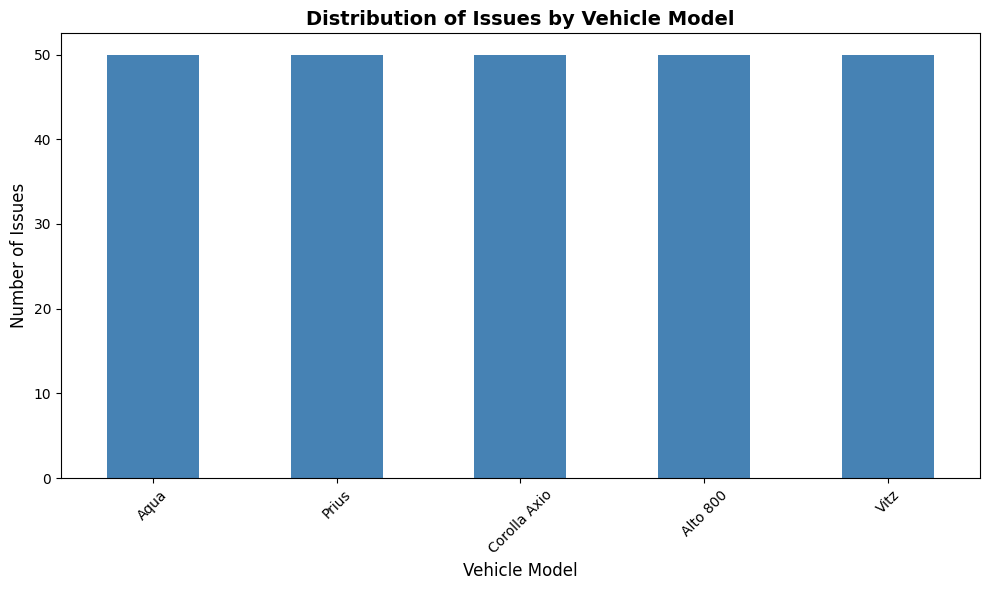

In [18]:
# Vehicle model distribution
print("=" * 60)
print("VEHICLE MODEL DISTRIBUTION")
print("=" * 60)
if 'model' in main_df.columns:
    model_counts = main_df['model'].value_counts()
    print(model_counts)
    
    # Visualization
    plt.figure(figsize=(10, 6))
    model_counts.plot(kind='bar', color='steelblue')
    plt.title('Distribution of Issues by Vehicle Model', fontsize=14, fontweight='bold')
    plt.xlabel('Vehicle Model', fontsize=12)
    plt.ylabel('Number of Issues', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

POWERTRAIN DISTRIBUTION
powertrain
Petrol             150
Hybrid (petrol)    100
Name: count, dtype: int64


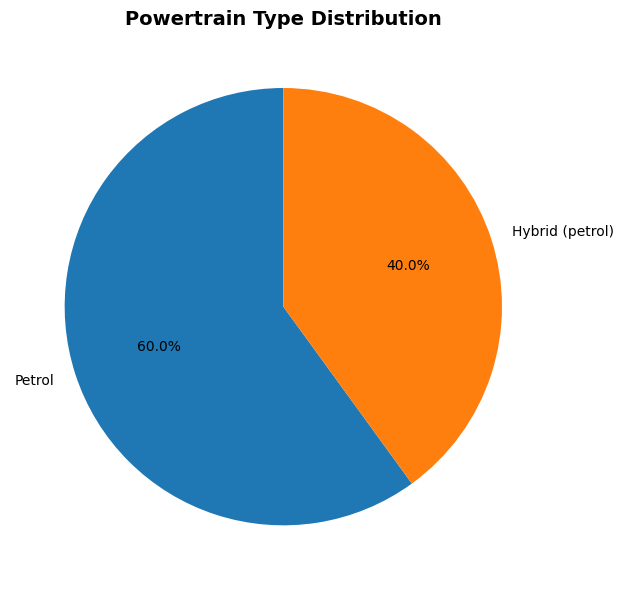

In [19]:
# Powertrain distribution
print("=" * 60)
print("POWERTRAIN DISTRIBUTION")
print("=" * 60)
if 'powertrain' in main_df.columns:
    powertrain_counts = main_df['powertrain'].value_counts()
    print(powertrain_counts)
    
    # Visualization
    plt.figure(figsize=(8, 6))
    plt.pie(powertrain_counts.values, labels=powertrain_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Powertrain Type Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

FALLBACK DATASET - INTENT DISTRIBUTION
intent
unknown_issue        86
ask_fallback_help    83
unknown_vehicle      81
Name: count, dtype: int64


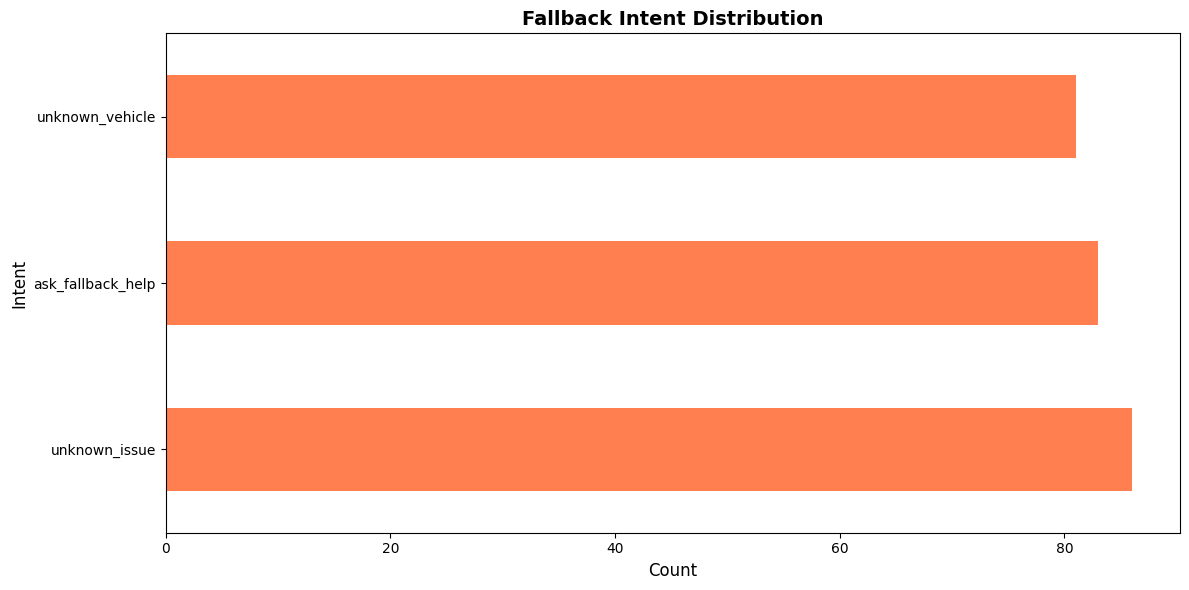

In [20]:
# Intent distribution in fallback dataset
print("=" * 60)
print("FALLBACK DATASET - INTENT DISTRIBUTION")
print("=" * 60)
if 'intent' in fallback_df.columns:
    intent_counts = fallback_df['intent'].value_counts()
    print(intent_counts)
    
    # Visualization
    plt.figure(figsize=(12, 6))
    intent_counts.plot(kind='barh', color='coral')
    plt.title('Fallback Intent Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Intent', fontsize=12)
    plt.tight_layout()
    plt.show()

## 5. Text Preprocessing Functions

In [21]:
class TextPreprocessor:
    """
    Comprehensive text preprocessing class for vehicle troubleshooting chatbot
    Supports both English and Sinhala text processing
    """
    
    def __init__(self, language='english'):
        self.language = language
        self.lemmatizer = WordNetLemmatizer()
        self.stemmer = PorterStemmer()
        
        # English stopwords
        self.stop_words_en = set(stopwords.words('english'))
        
        # Custom automotive stopwords to keep (they're important)
        self.automotive_keywords = {
            'engine', 'start', 'brake', 'battery', 'oil', 'fuel', 'check',
            'light', 'warning', 'noise', 'smell', 'leak', 'hot', 'cold',
            'ac', 'air', 'power', 'speed', 'wheel', 'tire', 'steering'
        }
        
        # Remove automotive keywords from stopwords
        self.stop_words_en = self.stop_words_en - self.automotive_keywords
        
        # Sinhala stopwords (common words)
        self.stop_words_si = {
            'මම', 'මා', 'මගේ', 'අපි', 'අප', 'ඔබ', 'ඔබේ', 'එය', 'එම', 'මේ', 'මෙම',
            'වේ', 'වෙයි', 'ද', 'හා', 'සහ', 'නම්', 'නමුත්', 'සඳහා'
        }
    
    def clean_text(self, text):
        """
        Basic text cleaning - remove special characters, extra spaces
        """
        if pd.isna(text):
            return ""
        
        text = str(text)
        
        # Convert to lowercase (only for English)
        if self.language == 'english':
            text = text.lower()
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+', '', text)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text)
        
        # Remove leading/trailing whitespace
        text = text.strip()
        
        return text
    
    def remove_special_characters(self, text, keep_periods=True):
        """
        Remove special characters but keep important punctuation
        """
        if keep_periods:
            # Keep letters, numbers, spaces, and periods
            text = re.sub(r'[^a-zA-Z0-9\s.\u0D80-\u0DFF]', '', text)
        else:
            # Keep only letters, numbers, and spaces (including Sinhala Unicode)
            text = re.sub(r'[^a-zA-Z0-9\s\u0D80-\u0DFF]', '', text)
        
        return text
    
    def remove_stopwords(self, text):
        """
        Remove stopwords based on language
        """
        tokens = word_tokenize(text) if self.language == 'english' else text.split()
        
        stop_words = self.stop_words_en if self.language == 'english' else self.stop_words_si
        
        filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
        
        return ' '.join(filtered_tokens)
    
    def lemmatize_text(self, text):
        """
        Lemmatize text (English only)
        """
        if self.language != 'english':
            return text
        
        tokens = word_tokenize(text)
        lemmatized = [self.lemmatizer.lemmatize(word) for word in tokens]
        return ' '.join(lemmatized)
    
    def stem_text(self, text):
        """
        Stem text (English only)
        """
        if self.language != 'english':
            return text
        
        tokens = word_tokenize(text)
        stemmed = [self.stemmer.stem(word) for word in tokens]
        return ' '.join(stemmed)
    
    def expand_contractions(self, text):
        """
        Expand common English contractions
        """
        contractions_dict = {
            "won't": "will not",
            "can't": "cannot",
            "n't": " not",
            "'re": " are",
            "'s": " is",
            "'d": " would",
            "'ll": " will",
            "'ve": " have",
            "'m": " am"
        }
        
        for contraction, expansion in contractions_dict.items():
            text = text.replace(contraction, expansion)
        
        return text
    
    def preprocess_pipeline(self, text, remove_stops=True, lemmatize=True, stem=False):
        """
        Complete preprocessing pipeline
        """
        # Step 1: Clean text
        text = self.clean_text(text)
        
        # Step 2: Expand contractions (English only)
        if self.language == 'english':
            text = self.expand_contractions(text)
        
        # Step 3: Remove special characters
        text = self.remove_special_characters(text, keep_periods=False)
        
        # Step 4: Remove stopwords
        if remove_stops:
            text = self.remove_stopwords(text)
        
        # Step 5: Lemmatize or Stem
        if lemmatize and self.language == 'english':
            text = self.lemmatize_text(text)
        elif stem and self.language == 'english':
            text = self.stem_text(text)
        
        return text

print("TextPreprocessor class created successfully!")

TextPreprocessor class created successfully!


## 6. Test Preprocessing Functions

In [22]:
# Test English preprocessing
preprocessor_en = TextPreprocessor(language='english')

test_texts = [
    "My car's engine won't start! There's a clicking noise.",
    "The brake pedal feels spongy and there's a burning smell.",
    "Check engine light is blinking - is it safe to drive???"
]

print("=" * 70)
print("ENGLISH TEXT PREPROCESSING TEST")
print("=" * 70)

for i, text in enumerate(test_texts, 1):
    print(f"\n{i}. Original: {text}")
    print(f"   Cleaned: {preprocessor_en.clean_text(text)}")
    print(f"   Preprocessed: {preprocessor_en.preprocess_pipeline(text)}")

ENGLISH TEXT PREPROCESSING TEST

1. Original: My car's engine won't start! There's a clicking noise.
   Cleaned: my car's engine won't start! there's a clicking noise.
   Preprocessed: car engine start clicking noise

2. Original: The brake pedal feels spongy and there's a burning smell.
   Cleaned: the brake pedal feels spongy and there's a burning smell.
   Preprocessed: brake pedal feel spongy burning smell

3. Original: Check engine light is blinking - is it safe to drive???
   Cleaned: check engine light is blinking - is it safe to drive???
   Preprocessed: check engine light blinking safe drive


In [23]:
# Test Sinhala preprocessing
preprocessor_si = TextPreprocessor(language='sinhala')

test_texts_si = [
    "මගේ මෝටර් රථය ස්ටාර්ට් වෙන්නේ නැහැ",
    "බ්‍රේක් එකේ ගැටලුවක් තියෙනවා",
    "එන්ජින් එකේ අමුතු ශබ්දයක් ඇහෙනවා"
]

print("=" * 70)
print("SINHALA TEXT PREPROCESSING TEST")
print("=" * 70)

for i, text in enumerate(test_texts_si, 1):
    print(f"\n{i}. Original: {text}")
    print(f"   Cleaned: {preprocessor_si.clean_text(text)}")
    print(f"   Preprocessed: {preprocessor_si.preprocess_pipeline(text)}")

SINHALA TEXT PREPROCESSING TEST

1. Original: මගේ මෝටර් රථය ස්ටාර්ට් වෙන්නේ නැහැ
   Cleaned: මගේ මෝටර් රථය ස්ටාර්ට් වෙන්නේ නැහැ
   Preprocessed: මෝටර් රථය ස්ටාර්ට් වෙන්නේ නැහැ

2. Original: බ්‍රේක් එකේ ගැටලුවක් තියෙනවා
   Cleaned: බ්‍රේක් එකේ ගැටලුවක් තියෙනවා
   Preprocessed: බ්රේක් එකේ ගැටලුවක් තියෙනවා

3. Original: එන්ජින් එකේ අමුතු ශබ්දයක් ඇහෙනවා
   Cleaned: එන්ජින් එකේ අමුතු ශබ්දයක් ඇහෙනවා
   Preprocessed: එන්ජින් එකේ අමුතු ශබ්දයක් ඇහෙනවා


## 7. Preprocess Main Dataset

In [24]:
# Create a copy for preprocessing
main_df_processed = main_df.copy()

# Initialize preprocessor
preprocessor = TextPreprocessor(language='english')

# Text columns to preprocess
text_columns = ['quick_checks', 'diagnostic_steps', 'recommended_actions', 'sri_lanka_notes', 'safety_note']

# Apply preprocessing to each column
for col in text_columns:
    if col in main_df_processed.columns:
        print(f"Processing column: {col}")
        main_df_processed[f'{col}_cleaned'] = main_df_processed[col].apply(preprocessor.clean_text)
        main_df_processed[f'{col}_processed'] = main_df_processed[col].apply(
            lambda x: preprocessor.preprocess_pipeline(x, remove_stops=True, lemmatize=True)
        )

print("\nMain dataset preprocessing completed!")
print(f"New shape: {main_df_processed.shape}")

Processing column: quick_checks
Processing column: diagnostic_steps
Processing column: recommended_actions
Processing column: sri_lanka_notes
Processing column: safety_note

Main dataset preprocessing completed!
New shape: (250, 20)


In [25]:
# Create combined text field for semantic search
main_df_processed['combined_text'] = (
    main_df_processed['quick_checks'].fillna('') + ' ' +
    main_df_processed['diagnostic_steps'].fillna('') + ' ' +
    main_df_processed['recommended_actions'].fillna('') + ' ' +
    main_df_processed['sri_lanka_notes'].fillna('')
)

main_df_processed['combined_text_processed'] = main_df_processed['combined_text'].apply(
    lambda x: preprocessor.preprocess_pipeline(x, remove_stops=True, lemmatize=True)
)

print("Combined text field created for semantic search!")
print("\nSample combined text:")
print(main_df_processed['combined_text_processed'].iloc[0][:300] + "...")

Combined text field created for semantic search!

Sample combined text:
confirm dashboard light flashing check ac airflow filter check tyre pressure wheel alignment inspect radiator fan operation test 12v battery voltage 124v measure fuel pressure injector response scan hybrid system reset code needed replace weak battery correct capacity frequent short trip reduce batt...


## 8. Preprocess Fallback Dataset

In [26]:
# Create a copy for preprocessing
fallback_df_processed = fallback_df.copy()

# Text columns to preprocess
fallback_text_columns = ['user_example', 'bot_reply', 'bot_questions', 'generic_quick_checks', 'safety_rules']

# Apply preprocessing
for col in fallback_text_columns:
    if col in fallback_df_processed.columns:
        print(f"Processing column: {col}")
        fallback_df_processed[f'{col}_cleaned'] = fallback_df_processed[col].apply(preprocessor.clean_text)
        fallback_df_processed[f'{col}_processed'] = fallback_df_processed[col].apply(
            lambda x: preprocessor.preprocess_pipeline(x, remove_stops=True, lemmatize=True)
        )

print("\nFallback dataset preprocessing completed!")
print(f"New shape: {fallback_df_processed.shape}")

Processing column: user_example
Processing column: bot_reply
Processing column: bot_questions
Processing column: generic_quick_checks
Processing column: safety_rules

Fallback dataset preprocessing completed!
New shape: (250, 18)


In [27]:
# Create combined text for fallback dataset
fallback_df_processed['combined_text'] = (
    fallback_df_processed['user_example'].fillna('') + ' ' +
    fallback_df_processed['bot_questions'].fillna('') + ' ' +
    fallback_df_processed['generic_quick_checks'].fillna('')
)

fallback_df_processed['combined_text_processed'] = fallback_df_processed['combined_text'].apply(
    lambda x: preprocessor.preprocess_pipeline(x, remove_stops=True, lemmatize=True)
)

print("Fallback combined text field created!")

Fallback combined text field created!


## 9. Text Analysis & Visualization

In [28]:
# Word frequency analysis
def get_word_frequency(text_series, top_n=20):
    """
    Get top N most frequent words from text series
    """
    all_words = []
    for text in text_series:
        if pd.notna(text):
            words = str(text).split()
            all_words.extend(words)
    
    word_freq = Counter(all_words)
    return word_freq.most_common(top_n)

# Get top words from main dataset
top_words_main = get_word_frequency(main_df_processed['combined_text_processed'], top_n=30)

print("=" * 70)
print("TOP 30 MOST FREQUENT WORDS - MAIN DATASET")
print("=" * 70)
for word, freq in top_words_main:
    print(f"{word:20s}: {freq:4d}")

TOP 30 MOST FREQUENT WORDS - MAIN DATASET
check               :  539
battery             :  416
fluid               :  393
inspect             :  385
system              :  260
brake               :  255
clean               :  215
replace             :  213
filter              :  212
level               :  186
12v                 :  173
fuel                :  172
pressure            :  169
leak                :  154
wheel               :  152
alignment           :  152
coolant             :  151
pad                 :  151
ac                  :  148
driving             :  146
scan                :  145
code                :  145
fan                 :  142
condition           :  133
radiator            :  129
air                 :  125
bleed               :  120
hybrid              :  112
spark               :  105
plug                :  105


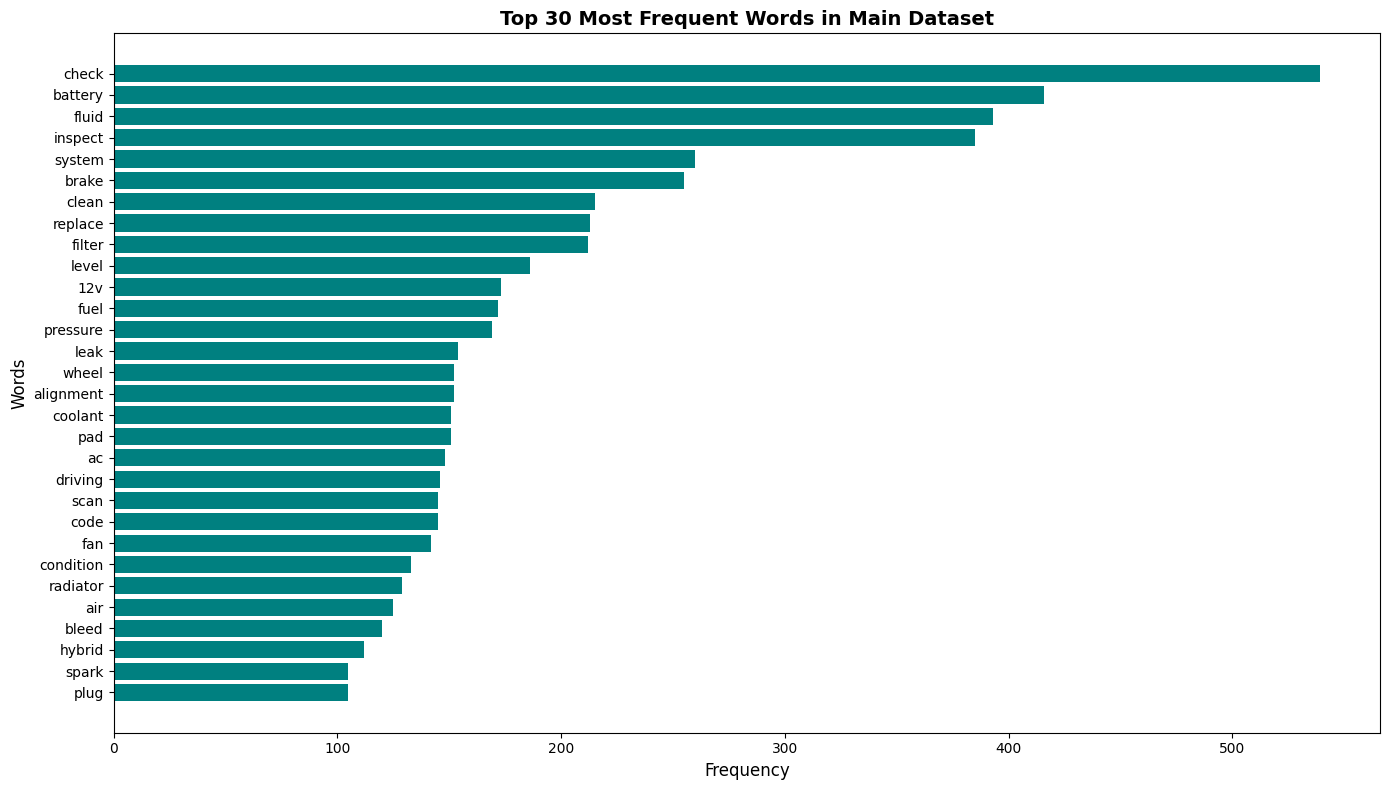

In [29]:
# Visualize word frequency
words, frequencies = zip(*top_words_main)

plt.figure(figsize=(14, 8))
plt.barh(words, frequencies, color='teal')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.title('Top 30 Most Frequent Words in Main Dataset', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

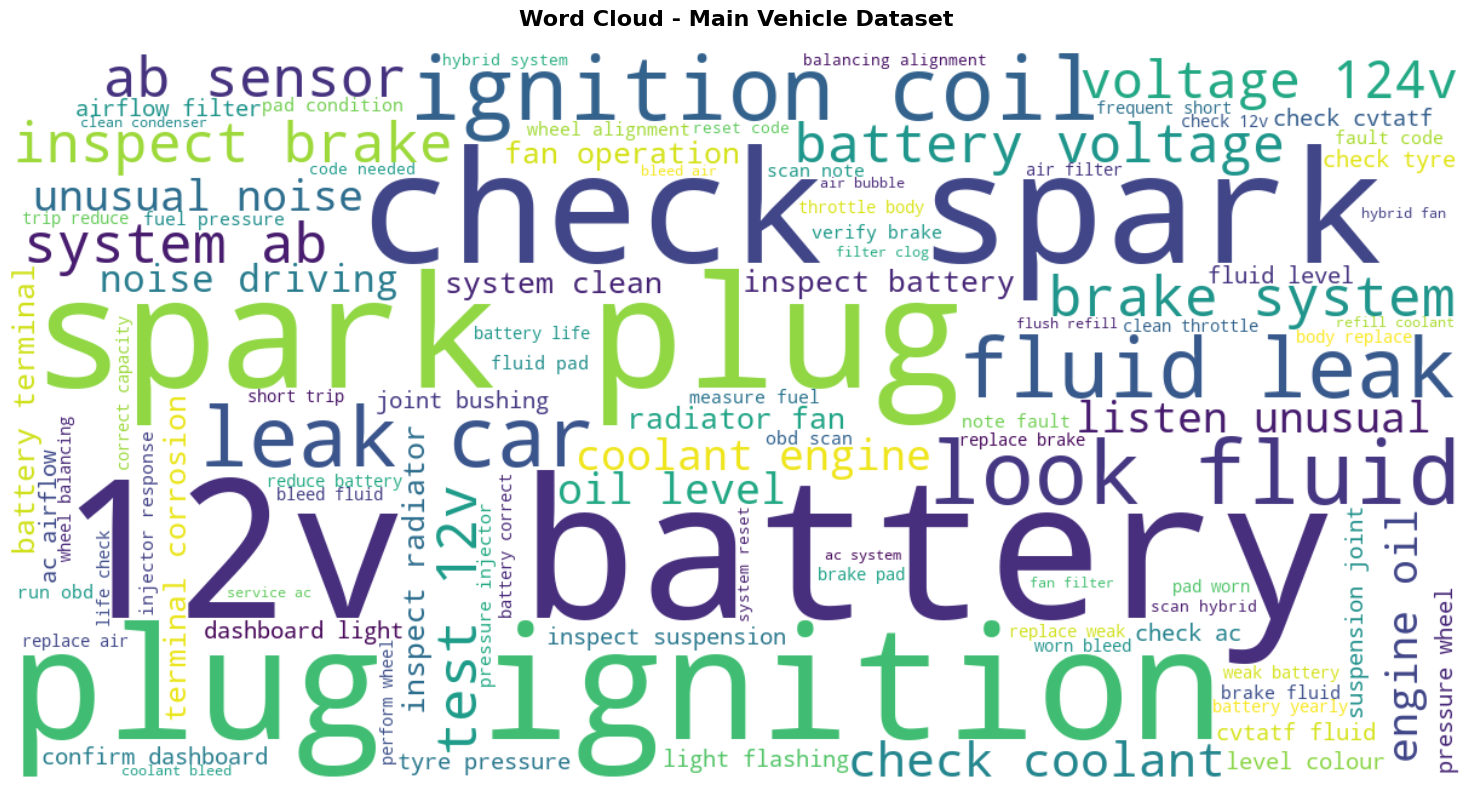

In [30]:
# Generate Word Cloud for main dataset
all_text_main = ' '.join(main_df_processed['combined_text_processed'].dropna())

wordcloud = WordCloud(width=1200, height=600, 
                     background_color='white',
                     colormap='viridis',
                     max_words=100).generate(all_text_main)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Main Vehicle Dataset', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [31]:
# Get top words from fallback dataset
top_words_fallback = get_word_frequency(fallback_df_processed['combined_text_processed'], top_n=30)

print("=" * 70)
print("TOP 30 MOST FREQUENT WORDS - FALLBACK DATASET")
print("=" * 70)
for word, freq in top_words_fallback:
    print(f"{word:20s}: {freq:4d}")

TOP 30 MOST FREQUENT WORDS - FALLBACK DATASET
example             :  250
fallback            :  250
question            :  250
light               :  146
happens             :  117
happen              :  112
car                 :  112
issue               :  102
noise               :   87
time                :   86
change              :   79
message             :   73
dashboard           :   73
occurs              :   65
check               :   65
whats               :   64
make                :   64
model               :   64
smell               :   64
look                :   55
vibration           :   52
driving             :   52
idle                :   52
recent              :   52
repair              :   52
fuel                :   52
petrol              :   48
diesel              :   48
hybrid              :   48


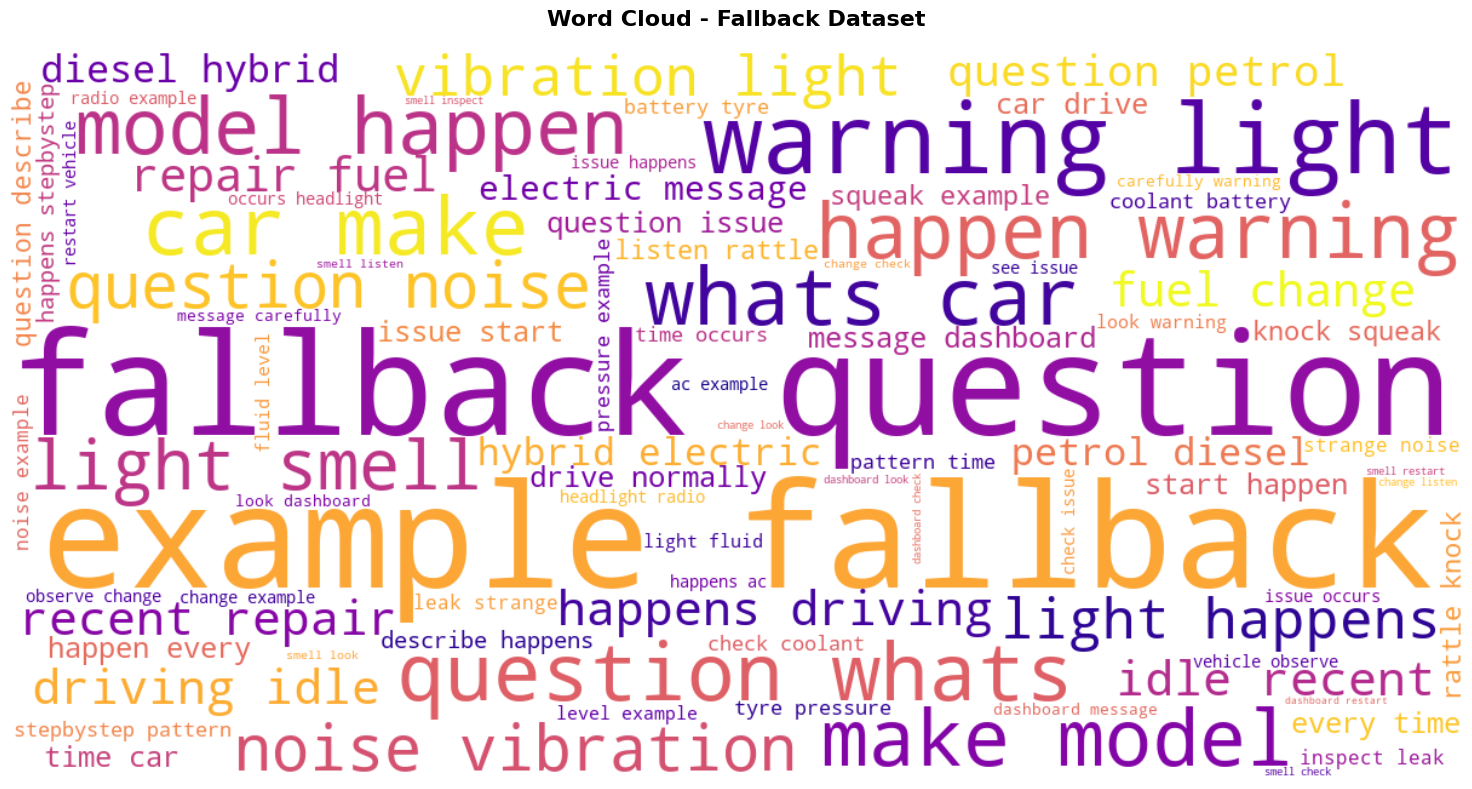

In [32]:
# Generate Word Cloud for fallback dataset
all_text_fallback = ' '.join(fallback_df_processed['combined_text_processed'].dropna())

wordcloud_fallback = WordCloud(width=1200, height=600, 
                              background_color='white',
                              colormap='plasma',
                              max_words=100).generate(all_text_fallback)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud_fallback, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Fallback Dataset', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 10. TF-IDF Vectorization

In [33]:
# Create TF-IDF vectorizer for main dataset
tfidf_vectorizer_main = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 3),  # unigrams, bigrams, trigrams
    min_df=2,
    max_df=0.8
)

# Fit and transform main dataset
tfidf_matrix_main = tfidf_vectorizer_main.fit_transform(
    main_df_processed['combined_text_processed'].fillna('')
)

print("Main Dataset TF-IDF Matrix Shape:", tfidf_matrix_main.shape)
print(f"Number of unique features: {len(tfidf_vectorizer_main.get_feature_names_out())}")

Main Dataset TF-IDF Matrix Shape: (250, 500)
Number of unique features: 500


In [34]:
# Get top TF-IDF features
feature_names = tfidf_vectorizer_main.get_feature_names_out()
tfidf_scores = tfidf_matrix_main.sum(axis=0).A1
top_tfidf_indices = tfidf_scores.argsort()[-30:][::-1]

print("=" * 70)
print("TOP 30 TF-IDF FEATURES - MAIN DATASET")
print("=" * 70)
for idx in top_tfidf_indices:
    print(f"{feature_names[idx]:40s}: {tfidf_scores[idx]:.4f}")

TOP 30 TF-IDF FEATURES - MAIN DATASET
system                                  : 13.9967
brake                                   : 13.1196
filter                                  : 12.1443
clean                                   : 12.0342
fuel                                    : 12.0078
replace                                 : 11.0741
level                                   : 11.0474
12v                                     : 10.6923
12v battery                             : 10.6923
pressure                                : 10.4501
alignment                               : 10.0866
wheel                                   : 10.0866
leak                                    : 10.0337
pad                                     : 9.7846
code                                    : 9.7841
scan                                    : 9.7841
ac                                      : 9.7710
driving                                 : 9.7094
coolant                                 : 9.6123
fan               

In [35]:
# Create TF-IDF vectorizer for fallback dataset
tfidf_vectorizer_fallback = TfidfVectorizer(
    max_features=300,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.9
)

# Fit and transform fallback dataset
tfidf_matrix_fallback = tfidf_vectorizer_fallback.fit_transform(
    fallback_df_processed['combined_text_processed'].fillna('')
)

print("Fallback Dataset TF-IDF Matrix Shape:", tfidf_matrix_fallback.shape)
print(f"Number of unique features: {len(tfidf_vectorizer_fallback.get_feature_names_out())}")

Fallback Dataset TF-IDF Matrix Shape: (250, 300)
Number of unique features: 300


## 11. Semantic Similarity Testing

In [36]:
def find_similar_issues(query, dataset_df, tfidf_vectorizer, tfidf_matrix, top_n=5):
    """
    Find most similar issues in dataset based on query
    """
    # Preprocess query
    query_processed = preprocessor.preprocess_pipeline(query)
    
    # Transform query to TF-IDF vector
    query_vector = tfidf_vectorizer.transform([query_processed])
    
    # Calculate cosine similarity
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
    
    # Get top N similar indices
    top_indices = similarities.argsort()[-top_n:][::-1]
    
    results = []
    for idx in top_indices:
        results.append({
            'index': idx,
            'similarity': similarities[idx],
            'data': dataset_df.iloc[idx]
        })
    
    return results

print("Similarity search function created!")

Similarity search function created!


In [37]:
# Test similarity search
test_queries = [
    "My car engine won't start",
    "Brake pedal feels soft and spongy",
    "Battery keeps dying overnight",
    "Air conditioning not cooling properly"
]

print("=" * 80)
print("SEMANTIC SIMILARITY SEARCH TESTING")
print("=" * 80)

for query in test_queries:
    print(f"\n{'='*80}")
    print(f"QUERY: {query}")
    print(f"{'='*80}")
    
    results = find_similar_issues(query, main_df_processed, tfidf_vectorizer_main, tfidf_matrix_main, top_n=3)
    
    for i, result in enumerate(results, 1):
        print(f"\n{i}. Similarity Score: {result['similarity']:.4f}")
        if 'model' in result['data']:
            print(f"   Vehicle Model: {result['data']['model']}")
        if 'quick_checks' in result['data']:
            quick_check = str(result['data']['quick_checks'])[:150]
            print(f"   Quick Check: {quick_check}...")
    print()

SEMANTIC SIMILARITY SEARCH TESTING

QUERY: My car engine won't start

1. Similarity Score: 0.1130
   Vehicle Model: Vitz
   Quick Check: Inspect battery terminals for corrosion. | Look for fluid leaks under the car. | Check coolant and engine oil levels....

2. Similarity Score: 0.1105
   Vehicle Model: Aqua
   Quick Check: Check A/C airflow and filter. | Check coolant and engine oil levels. | Look for fluid leaks under the car....

3. Similarity Score: 0.1093
   Vehicle Model: Corolla Axio
   Quick Check: Check A/C airflow and filter. | Check coolant and engine oil levels. | Look for fluid leaks under the car....


QUERY: Brake pedal feels soft and spongy

1. Similarity Score: 0.1631
   Vehicle Model: Corolla Axio
   Quick Check: Verify brake fluid and pad condition. | Check A/C airflow and filter. | Inspect battery terminals for corrosion....

2. Similarity Score: 0.1583
   Vehicle Model: Prius
   Quick Check: Verify brake fluid and pad condition. | Listen for unusual noises when dri

## 12. Export Processed Data

In [38]:
# Save processed datasets
main_df_processed.to_csv('main_dataset_processed.csv', index=False)
fallback_df_processed.to_csv('fallback_dataset_processed.csv', index=False)

print("Processed datasets saved!")
print("- main_dataset_processed.csv")
print("- fallback_dataset_processed.csv")

Processed datasets saved!
- main_dataset_processed.csv
- fallback_dataset_processed.csv


In [39]:
# Save TF-IDF vectorizers for later use
import pickle

with open('tfidf_vectorizer_main.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer_main, f)

with open('tfidf_vectorizer_fallback.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer_fallback, f)

print("TF-IDF vectorizers saved!")
print("- tfidf_vectorizer_main.pkl")
print("- tfidf_vectorizer_fallback.pkl")

TF-IDF vectorizers saved!
- tfidf_vectorizer_main.pkl
- tfidf_vectorizer_fallback.pkl


In [40]:
# Save TF-IDF matrices
from scipy.sparse import save_npz

save_npz('tfidf_matrix_main.npz', tfidf_matrix_main)
save_npz('tfidf_matrix_fallback.npz', tfidf_matrix_fallback)

print("TF-IDF matrices saved!")
print("- tfidf_matrix_main.npz")
print("- tfidf_matrix_fallback.npz")

TF-IDF matrices saved!
- tfidf_matrix_main.npz
- tfidf_matrix_fallback.npz


## 13. Dataset Statistics Summary

In [41]:
# Create comprehensive summary
print("=" * 80)
print("DATASET PREPROCESSING SUMMARY")
print("=" * 80)

print("\n📊 MAIN DATASET:")
print(f"  - Total records: {len(main_df_processed)}")
print(f"  - Total columns: {len(main_df_processed.columns)}")
if 'model' in main_df_processed.columns:
    print(f"  - Unique vehicle models: {main_df_processed['model'].nunique()}")
    print(f"  - Models: {', '.join(main_df_processed['model'].unique())}")
if 'powertrain' in main_df_processed.columns:
    print(f"  - Powertrain types: {', '.join(main_df_processed['powertrain'].unique())}")
print(f"  - TF-IDF features: {tfidf_matrix_main.shape[1]}")

print("\n📊 FALLBACK DATASET:")
print(f"  - Total records: {len(fallback_df_processed)}")
print(f"  - Total columns: {len(fallback_df_processed.columns)}")
if 'intent' in fallback_df_processed.columns:
    print(f"  - Unique intents: {fallback_df_processed['intent'].nunique()}")
print(f"  - TF-IDF features: {tfidf_matrix_fallback.shape[1]}")

print("\n✅ PREPROCESSING COMPLETED SUCCESSFULLY!")
print("\n📁 Output Files:")
print("  1. main_dataset_processed.csv")
print("  2. fallback_dataset_processed.csv")
print("  3. tfidf_vectorizer_main.pkl")
print("  4. tfidf_vectorizer_fallback.pkl")
print("  5. tfidf_matrix_main.npz")
print("  6. tfidf_matrix_fallback.npz")
print("=" * 80)

DATASET PREPROCESSING SUMMARY

📊 MAIN DATASET:
  - Total records: 250
  - Total columns: 22
  - Unique vehicle models: 5
  - Models: Aqua, Prius, Corolla Axio, Alto 800, Vitz
  - Powertrain types: Hybrid (petrol), Petrol
  - TF-IDF features: 500

📊 FALLBACK DATASET:
  - Total records: 250
  - Total columns: 20
  - Unique intents: 3
  - TF-IDF features: 300

✅ PREPROCESSING COMPLETED SUCCESSFULLY!

📁 Output Files:
  1. main_dataset_processed.csv
  2. fallback_dataset_processed.csv
  3. tfidf_vectorizer_main.pkl
  4. tfidf_vectorizer_fallback.pkl
  5. tfidf_matrix_main.npz
  6. tfidf_matrix_fallback.npz


## 14. Next Steps

After completing this preprocessing notebook, you can proceed with:

1. **Gemini API Integration**: Use the processed data with Gemini API for advanced semantic search
2. **Chatbot Development**: Build the main chatbot logic using the preprocessed datasets
3. **Fallback System**: Implement diagnostic question flow using fallback dataset
4. **Voice Integration**: Add speech-to-text and text-to-speech capabilities
5. **Warning Light Recognition**: Integrate Gemini Vision API for dashboard image analysis
6. **Multilingual Support**: Add Sinhala language processing and translation

### Recommended File Structure:
```
vehicle-chatbot/
├── data/
│   ├── sri_lanka_vehicle_dataset_5models_englishonly.xlsx
│   ├── fallback_dataset.xlsx
│   ├── main_dataset_processed.csv
│   ├── fallback_dataset_processed.csv
│   ├── tfidf_vectorizer_main.pkl
│   ├── tfidf_vectorizer_fallback.pkl
│   ├── tfidf_matrix_main.npz
│   └── tfidf_matrix_fallback.npz
├── notebooks/
│   ├── nlp_preprocessing.ipynb (this notebook)
│   ├── gemini_integration.ipynb
│   └── chatbot_testing.ipynb
└── app/
    ├── main.py
    ├── gemini_api.py
    └── preprocessor.py
```